<a href="https://colab.research.google.com/github/YABIGAIL23/Sistemas-Financieros/blob/main/Codigo_VWMA_y_MACD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea: Sistema de Análisis Técnico Cuantitativo (VWMA y MACD)

**Equipo:** 4  
**Fecha:**  03 de Junio de 2026  
**Materia / Curso:** Sistemas Financieros y Comerciales

---

## 1. Introducción
El análisis técnico es una disciplina financiera que evalúa las inversiones e identifica las oportunidades de comercio mediante el análisis de tendencias estadísticas recopiladas de la actividad comercial, como el movimiento de precios y el volumen.

El objetivo de esta tarea es desarrollar un script interactivo en Python que automatice la descarga de datos históricos de activos financieros reales y calcule dos de los indicadores técnicos más utilizados en los mercados: la **Media Móvil Ponderada por Volumen (VWMA)** y la **Media Móvil de Convergencia/Divergencia (MACD)**.

---

## 2. Definiciones Teóricas

### A. Media Móvil Ponderada por Volumen (VWMA)
A diferencia de una Media Móvil Simple (SMA) que solo promedia los precios de cierre, la **VWMA** da mayor peso o importancia a los días en los que hubo un mayor volumen de transacciones (liquidez). Esto permite identificar si una tendencia de precios está respaldada por el interés real del mercado o si es un movimiento débil con poco volumen.

La fórmula matemática para una ventana de $n$ períodos es:

$$\text{VWMA}_n = \frac{\sum_{i=1}^{n} (\text{Precio de Cierre}_i \times \text{Volumen}_i)}{\sum_{i=1}^{n} \text{Volumen}_i}$$

* **Interpretación:** Si el precio actual está por encima de la VWMA, el mercado se encuentra en una tendencia alcista respaldada por volumen institucional.

### B. Media Móvil de Convergencia/Divergencia (MACD)
El **MACD** es un indicador de impulso (momentum) que sigue la tendencia y muestra la relación entre dos medias móviles exponenciales (EMA) de los precios de un activo. Se compone de tres elementos principales:

1.  **Línea MACD (MACD Line):** Es la diferencia entre una EMA rápida (normalmente de 12 períodos) y una EMA lenta (normalmente de 26 períodos).

$$\text{MACD Line} = \text{EMA}_{12}(\text{Close}) - \text{EMA}_{26}(\text{Close})$$

2.  **Línea de Señal (Signal Line):** Es una EMA de la propia línea MACD (normalmente de 9 períodos). Actúa como un disparador para señales de compra o venta.

    $$\text{Signal Line} = \text{EMA}_{9}(\text{MACD Line})$$
    
3.  **Histograma:** Es la diferencia visual entre la Línea MACD y la Línea de Señal.
    $$\text{Histograma} = \text{MACD Line} - \text{Signal Line}$$

* **Interpretación:** Cuando el histograma pasa de negativo (rojo) a positivo (verde), indica un cruce alcista y un posible cambio de tendencia a favor de los compradores.

---

## 3. Desarrollo del Código
A continuación, se presenta la implementación del sistema estructurada por módulos funcionales.


###Librerías
En esta primera sección importamos las herramientas necesarias para el proyecto:
* `yfinance`: Para descargar datos financieros reales desde Yahoo Finance.
* `pandas` y `numpy`: Para la manipulación de datos y cálculos matemáticos.
* `matplotlib.pyplot`: Para la visualización gráfica de los indicadores.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###Interfaz de Usuario (Menús de Selección)
Creamos dos menús interactivos en consola utilizando diccionarios:
1. **Menú de Acciones:** Permite al usuario elegir entre 5 empresas (Coca-Cola, Apple, Google, Microsoft y Amazon).
2. **Menú de Ventanas:** Permite definir la sensibilidad del indicador VWMA seleccionando períodos cortos (5), medianos (10) o largos (20).

In [2]:
# --- MENÚ DE ACCIONES ---
acciones = {
    "1": "KO",      # Coca-Cola
    "2": "AAPL",    # Apple
    "3": "GOOGL",   # Google
    "4": "MSFT",    # Microsoft
    "5": "AMZN"     # Amazon
}

print("Menú de acciones")
print("1. Coca-Cola")
print("2. Apple")
print("3. Google")
print("4. Microsoft")
print("5. Amazon")

opcion = input("Elige una acción: ")
clave = acciones[opcion]
print("Elegiste:", clave)

# --- MENÚ DE TAMAÑOS DE VENTANA (NUEVO) ---
ventanas = {
    "1": 5,
    "2": 10,
    "3": 20
}

print("\nMenú de Tamaños de Ventana")
print("1. Ventana Corta (5 períodos)")
print("2. Ventana Mediana (10 períodos)")
print("3. Ventana Larga (20 períodos)")

opcion_v = input("Elige una ventana para la VWMA: ")
n = ventanas[opcion_v]
print("Elegiste tamaño de ventana n =", n)

Menú de acciones
1. Coca-Cola
2. Apple
3. Google
4. Microsoft
5. Amazon
Elige una acción: 1
Elegiste: KO

Menú de Tamaños de Ventana
1. Ventana Corta (5 períodos)
2. Ventana Mediana (10 períodos)
3. Ventana Larga (20 períodos)
Elige una ventana para la VWMA: 1
Elegiste tamaño de ventana n = 5


###Descarga de Datos Históricos
Utilizamos la API de `yfinance` para extraer el histórico de precios de la acción seleccionada durante el último año.
*Nota: Se realiza un aplanamiento de las columnas (`get_level_values(0)`) para asegurar que el DataFrame sea de un solo nivel y evitar conflictos en los cálculos posteriores.*

In [3]:
datos = yf.download(
    clave,
    start="2025-05-18",
    end="2026-05-19"
)
datos.columns = datos.columns.get_level_values(0)

/tmp/ipykernel_1778/959877604.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(
[*********************100%***********************]  1 of 1 completed


###Cálculo de Indicadores Técnicos
Realizamos las operaciones matemáticas para obtener dos indicadores clave:

1. **VWMA (Volume Weighted Moving Average):** Multiplica el precio de cierre por el volumen y calcula su media móvil para reflejar la fuerza del mercado según la liquidez. La fórmula matemática aplicada es:
$$\text{VWMA} = \frac{\sum (\text{Close} \times \text{Volume})}{\sum \text{Volume}}$$

2. **MACD (Moving Average Convergence Divergence):** Calculamos la diferencia entre dos medias móviles exponenciales (EMA de 12 y 26 períodos) para obtener la `MACD_Line`. Luego, calculamos su propia EMA de 9 períodos (`Signal_Line`). La diferencia entre ambas genera el `Histograma`.

In [4]:
# --- CÁLCULO DE INDICADORES (VWMA y MACD) ---
#1. VWMA (Media Móvil Ponderada por Volumen)
pv = datos["Close"] * datos["Volume"]
datos[f"VWMA_{n}"] = pv.rolling(window=n).sum() / datos["Volume"].rolling(window=n).sum()

#2. MACD (Línea MACD, Línea de Señal e Histograma)
ema12 = datos["Close"].ewm(span=12, adjust=False).mean()
ema26 = datos["Close"].ewm(span=26, adjust=False).mean()

datos["MACD_Line"] = ema12 - ema26
datos["Signal_Line"] = datos["MACD_Line"].ewm(span=9, adjust=False).mean()
datos["Histograma"] = datos["MACD_Line"] - datos["Signal_Line"]

#Despliegue de los resultados en consola
print("\nÚltimos 10 registros calculados:")
print(datos[["Close", "Volume", f"VWMA_{n}", "MACD_Line", "Signal_Line", "Histograma"]].tail(10))


Últimos 10 registros calculados:
Price           Close    Volume     VWMA_5  MACD_Line  Signal_Line  Histograma
Date                                                                          
2026-05-05  78.480003  11637500  78.607364   0.557209     0.242496    0.314714
2026-05-06  79.230003  14060300  78.667095   0.652197     0.324436    0.327761
2026-05-07  78.430000  16531400  78.588201   0.655368     0.390622    0.264746
2026-05-08  78.419998  12447200  78.558649   0.649586     0.442415    0.207171
2026-05-11  78.660004  10967900  78.646749   0.656798     0.485292    0.171507
2026-05-12  80.029999  19883100  79.045231   0.764252     0.541084    0.223168
2026-05-13  80.260002  12357000  79.217188   0.858077     0.604483    0.253595
2026-05-14  80.449997  10642000  79.611366   0.936965     0.670979    0.265986
2026-05-15  80.820000  17527200  80.115913   1.017610     0.740305    0.277305
2026-05-18  81.199997  12375500  80.519628   1.099510     0.812146    0.287364


###Visualización Gráfica
Generamos un panel con dos subgráficos (`subplots`) compartiendo el eje X (fechas) para facilitar el análisis visual:
* **Panel Superior:** Muestra la evolución del Precio de Cierre frente a la línea de la VWMA elegida.
* **Panel Inferior:** Muestra las líneas del MACD y su Histograma, el cual cambia dinámicamente de color (verde para valores positivos y rojo para negativos) para identificar rápidamente el impulso del mercado.

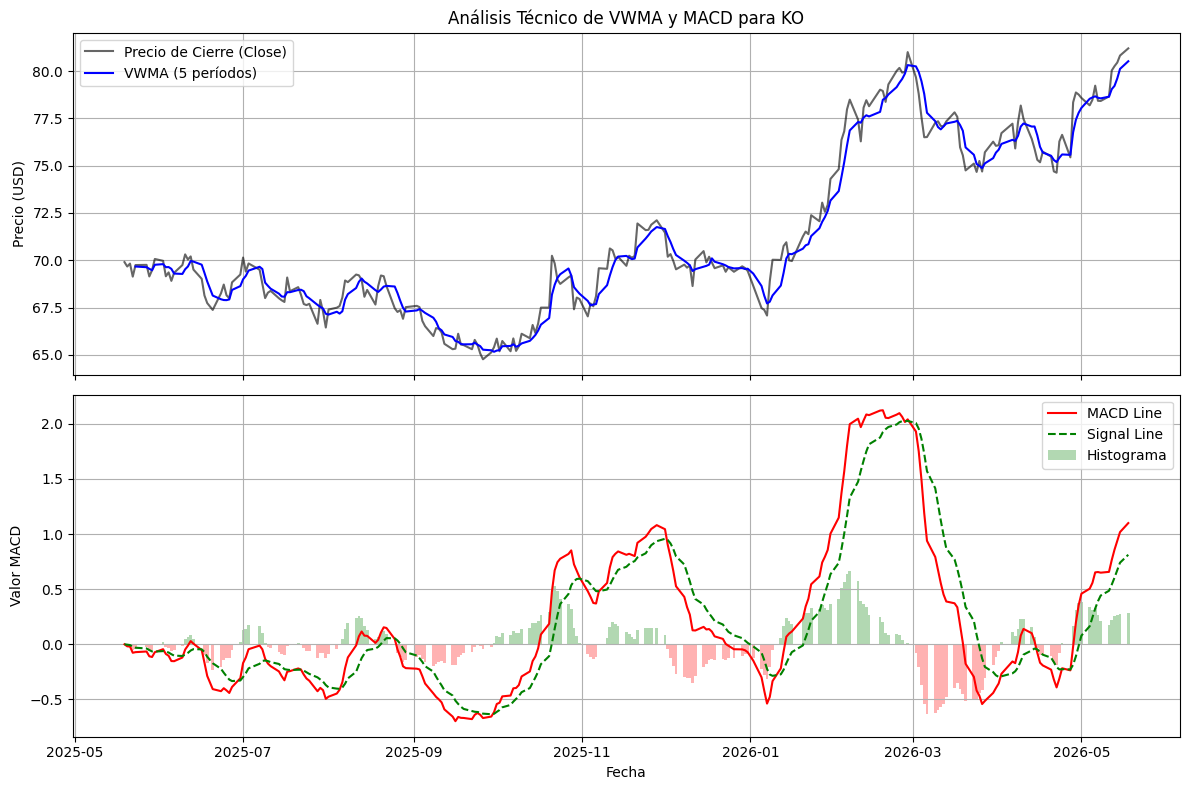

In [5]:
# --- GRÁFICAS DEL SISTEMA ---
# Creamos dos subgráficos alineados verticalmente
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfica 1: Precio de Cierre y VWMA
ax1.plot(datos["Close"], label="Precio de Cierre (Close)", color="black", alpha=0.6)
ax1.plot(datos[f"VWMA_{n}"], label=f"VWMA ({n} períodos)", color="blue")
ax1.set_title(f"Análisis Técnico de VWMA y MACD para {clave}")
ax1.set_ylabel("Precio (USD)")
ax1.legend()
ax1.grid(True)

# Gráfica 2: MACD (Líneas e Histograma)
ax2.plot(datos["MACD_Line"], label="MACD Line", color="red")
ax2.plot(datos["Signal_Line"], label="Signal Line", color="green", linestyle="--")

# Colores dinámicos del histograma (Verde positivo / Rojo negativo)
colores_hist = np.where(datos["Histograma"] >= 0, 'green', 'red')
ax2.bar(datos.index, datos["Histograma"], color=colores_hist, alpha=0.3, width=1.0, label="Histograma")
ax2.set_ylabel("Valor MACD")
ax2.set_xlabel("Fecha")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

###Exportación y Descarga de Resultados
Finalmente, limpiamos el DataFrame eliminando las filas iniciales que no tienen datos calculados debido a las ventanas móviles (`dropna()`). Exportamos el resultado final a un archivo de Excel y usamos las librerías nativas de Google Colab para disparar la descarga automática del archivo `.xlsx` directamente a nuestra computadora.

In [6]:
# --- EXPORTACIÓN Y DESCARGA ---
datos_excel = datos.dropna()
datos_excel.to_excel("vwma_macd_analisis.xlsx")

from google.colab import files
files.download("vwma_macd_analisis.xlsx")

print("\nPrimeros 10 registros exportados al Excel limpio:")
print(datos_excel[[f"VWMA_{n}", "MACD_Line", "Signal_Line", "Histograma"]].head(10))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Primeros 10 registros exportados al Excel limpio:
Price          VWMA_5  MACD_Line  Signal_Line  Histograma
Date                                                     
2025-05-23  69.671026  -0.071339    -0.031112   -0.040228
2025-05-27  69.634249  -0.065385    -0.037966   -0.027419
2025-05-28  69.549493  -0.108816    -0.052136   -0.056680
2025-05-29  69.473011  -0.115244    -0.064758   -0.050487
2025-05-30  69.762853  -0.071678    -0.066142   -0.005536
2025-06-02  69.797015  -0.044480    -0.061809    0.017330
2025-06-03  69.635359  -0.087785    -0.067004   -0.020780
2025-06-04  69.641714  -0.104432    -0.074490   -0.029942
2025-06-05  69.546182  -0.151947    -0.089981   -0.061965
2025-06-06  69.298171  -0.153331    -0.102651   -0.050679
